In [1]:
import requests 
from urllib.parse import urlencode
import urllib3
import matplotlib.pyplot as plt
urllib3.disable_warnings()

In [2]:
# lon, lat = 37.61191755, 55.7965029
# param={"horizon":1,
#     'planchers_tot':56, # общее количество этажей
#     'height':179.9, # высота обхекта (м)
#     'souterrain':2, # количество подземных этажей
#     'planchers_sur':54, # количество надземных этажей
#     'n_app':450, # количество квартир
#     'superficie_tot':38910, # общая площадь объекта 
#     'espace_de_vie':22301.0, # жилая площадь объекта
#     'lon':lon, # долгота 
#     'lat':lat # широта 
# }

param=dict(horizon=1.5,
planchers_tot=13,
height=45,
souterrain=1 ,
planchers_sur=12 ,
n_app=320 ,
superficie_tot=37808.7 ,
espace_de_vie=17568.2 ,
lon=37.79118873301258 ,
lat=55.640345821167806 )

url = 'http://127.0.0.1:5000/price?'+urlencode(param)
print(url)

r = requests.get(url, verify=False)
if r.status_code!=200:
    print('Failure', r.status_code)
print(r.text)

http://127.0.0.1:5000/price?horizon=1.5&planchers_tot=13&height=45&souterrain=1&planchers_sur=12&n_app=320&superficie_tot=37808.7&espace_de_vie=17568.2&lon=37.79118873301258&lat=55.640345821167806
{
  "code": 0,
  "csv_name": "results/prognose_2025-10-13_12-14-14.csv",
  "dates": [
    "2025-10-01",
    "2026-01-01",
    "2026-04-01",
    "2026-07-01",
    "2026-10-01",
    "2027-01-01",
    "2027-04-01",
    "2027-07-01",
    "2027-10-01"
  ],
  "excel_name": "results/prognose_2025-10-13_12-14-14.xlsx",
  "forecast_horizon": [
    0.0,
    0.25,
    0.5,
    0.75,
    1.0,
    1.25,
    1.5,
    1.75,
    2.0
  ],
  "lat": 55.640345821167806,
  "lon": 37.79118873301258,
  "official": [
    1.0,
    1.012,
    1.023,
    1.036,
    1.047,
    1.059,
    1.07,
    1.082,
    1.093
  ],
  "price_index": [
    1.0,
    1.058,
    1.091,
    1.128,
    1.16,
    1.192,
    1.223,
    1.254,
    1.282
  ],
  "pricemetr_dom": [
    281.35,
    297.58,
    306.9,
    317.33,
    326.49,
    3

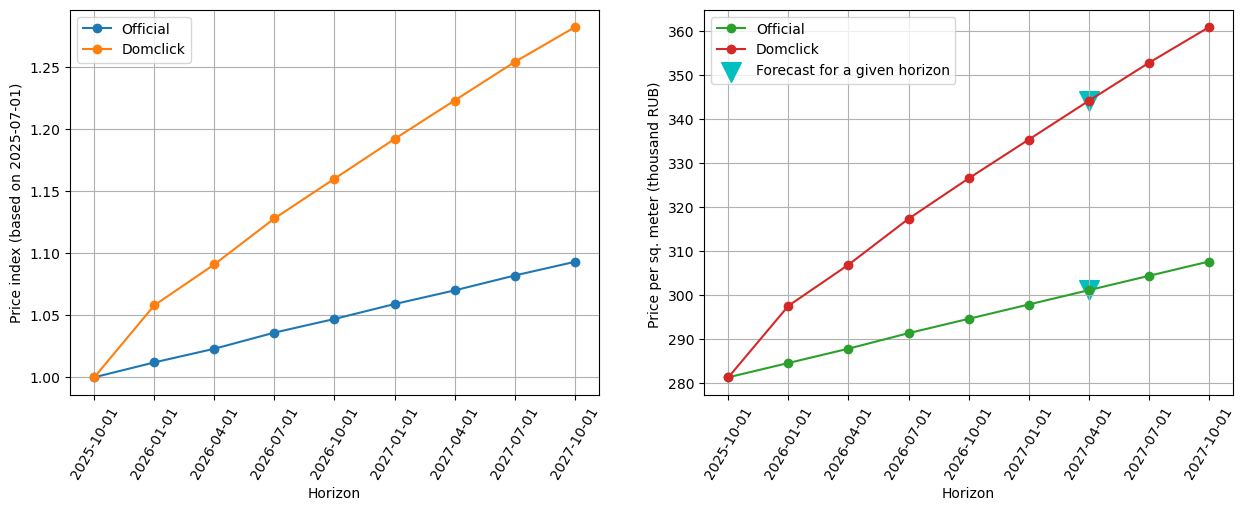

In [3]:
res=eval(r.text)
plt.figure(figsize=(15,5))

plt.subplot(1,2,1)
plt.plot(res['forecast_horizon'], res['official'], label='Official', marker='o')
plt.plot(res['forecast_horizon'], res['price_index'], label='Domclick', marker='o')
plt.legend()
plt.grid()
plt.xlabel('Horizon')
plt.ylabel('Price index (based on 2025-07-01)')
plt.xticks(res['forecast_horizon'], res['dates'], rotation=60)

plt.subplot(1,2,2)
plt.plot(res['forecast_horizon'], res['pricemetr_off'], label='Official', marker='o', c='tab:green')
plt.plot(res['forecast_horizon'], res['pricemetr_dom'], label='Domclick', marker='o', c='tab:red')
plt.scatter(param["horizon"],res["pricemetr_future_dom"], marker='v',s=200, c='c', label='Forecast for a given horizon')
plt.scatter(param["horizon"],res["pricemetr_future_off"], marker='v',s=200, c='c' )
plt.legend()
plt.grid()
plt.xlabel('Horizon')
plt.ylabel('Price per sq. meter (thousand RUB) ')
plt.xticks(res['forecast_horizon'], res['dates'], rotation=60)

plt.show()

In [4]:
lon, lat = 37.61191755, 55.7965029
param={
    'lon':lon, # долгота 
    'lat':lat, # широта 
    'year':2026, # прогнозируемый год
    'month':12, # прогнозируемый месяц
}
url= 'http://127.0.0.1:5000/demand?'+urlencode(param)
print(url)
r = requests.get(url, verify=False)
if r.status_code!=200:
    print('Failure', r.status_code)
eval(r.text)

http://127.0.0.1:5000/demand?lon=37.61191755&lat=55.7965029&year=2026&month=12


{'1': 0.42,
 '2': 0.35,
 '3': 0.04,
 '4': 0.19,
 'code': 0,
 'date': '2026-12-01',
 'district': 'Марьина Роща',
 'response': 'Okay'}